# Alliteration Density & Euphony Index — Historical Human-Eval Poems
Runs alliteration density from `PoemMetrics` (`metrics.py`) and the euphony index from `madhurya.py` (mādhurya, v1.1) on `human_evals/human_eval_poems_historical.json` (500 poems, all passing the full *historical* chandassu/prāsa/yati profile) and summarises both metrics.

- **Alliteration density** ∈ [0, ∞) (≈ 0–1 in practice): character-weighted repetition of consonant 1–3-grams, per consonant.
- **Euphony index** (`madhurya.py`, `M = I − P`): per-akshara class weights (+1 mādhura … −1 paruṣa) averaged over the poem, minus a *pile-up* penalty for adjacent harsh aksharas. Also reported: inventory `I`, pile-up `P`, Parker-scale sonority, and the rubric level (0 harsh … 4 soft) from the reference-corpus baseline.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from metrics import PoemMetrics
import madhurya as md

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160, "display.max_columns", 40, "display.float_format", "{:.4f}".format)

DATA = Path("../human_evals/human_eval_poems_historical.json")
data = json.loads(DATA.read_text(encoding="utf-8"))
poems = data["poems"]
print(data["dataset"], "| profile:", data["compliance_profile"], "| poems:", len(poems))

chandohasam_human_eval_v1 | profile: historical | poems: 500


## 1. Compute metrics per poem

In [2]:
pm = PoemMetrics()
baseline = md.load_baseline()
CLASSES = list(md.CLASSES)
rows, failures = [], []
for p in poems:
    try:
        eu = md.score_poem(p["lines"], baseline)
        al = pm.alliteration_density(p["lines"])
    except Exception as e:
        failures.append((p["eval_id"], repr(e))); continue
    if eu["madhurya"] is None or al is None:
        failures.append((p["eval_id"], "no tokens")); continue
    rows.append(dict(
        eval_id=p["eval_id"], source=p["source_dataset"], meter=p["meter_id"],
        author=p.get("author"), strictest=p.get("strictest_profile"), n_lines=p["line_count"],
        euphony=eu["madhurya"], inventory=eu["inventory"], pileup=eu["pileup"], sonority=eu["sonority"],
        level=eu["level"], label=eu["label"], n_aksharas=eu["n_aksharas"],
        **{f"share_{c}": eu["classes"][c] / eu["n_aksharas"] for c in CLASSES},
        longest_harsh_run=(eu["harshest_run"] or {}).get("length", 0),
        alliteration=al["alliteration_density"],
        allit_1=al["by_length"][1], allit_2=al["by_length"][2], allit_3=al["by_length"][3],
        consonants=al["consonants"], top_repeat=al["top_repeats"][0] if al["top_repeats"] else None,
    ))
df = pd.DataFrame(rows)
print(f"scored {len(df)} / {len(poems)} poems; failures: {len(failures)}", failures[:5])
df.head()

scored 500 / 500 poems; failures: 0 []


,eval_id,source,meter,author,strictest,n_lines,euphony,inventory,pileup,sonority,level,label,n_aksharas,share_madhura,share_sonorant,share_voiced,share_voiceless,share_conjunct,share_parusha,longest_harsh_run,alliteration,allit_1,allit_2,allit_3,consonants,top_repeat
0,he_0001,bhagavatam,utpalamala,Pothana,strict,4,0.0312,0.0875,0.0563,10.6880,2,balanced,80,0.0750,0.4375,0.1750,0.1500,0.0625,0.1000,2,1.8627,0.8529,0.6863,0.3235,102,"(y, 13)"
1,he_0002,generated,tetagiti,Gemini 3.7 Flash (generated),strict,4,-0.3039,0.0294,0.3333,10.7940,0,harsh,51,0.0980,0.3922,0.1569,0.1765,0.0000,0.1765,7,0.8302,0.7170,0.1132,0.0000,53,"(v, 8)"
2,he_0003,vemana,kandamu,Vemana,strict,4,0.1038,0.2170,0.1132,11.3630,3,leaning_soft,53,0.0189,0.6792,0.0755,0.1132,0.0566,0.0566,5,1.2586,0.7414,0.4138,0.1034,58,"(n, 16)"
3,he_0004,kuchimanchi,sardulavikriditamu,Kūcimañci Timmakavi,strict,4,-0.4474,-0.1579,0.2895,10.2330,0,harsh,76,0.1053,0.2368,0.1053,0.2500,0.0921,0.2105,4,1.5612,0.8265,0.6122,0.1224,98,"(th, 15)"
4,he_0005,kuchimanchi,totakamu,Kūcimañci Timmakavi,strict,4,0.0938,0.1146,0.0208,10.4250,3,leaning_soft,48,0.1250,0.3750,0.1875,0.1667,0.0625,0.0833,2,0.9815,0.7037,0.2222,0.0556,54,"(l, 10)"


## 2. Descriptive statistics

In [3]:
def describe(s):
    q = s.quantile([.01, .05, .25, .5, .75, .95, .99])
    return pd.Series({
        "n": s.size, "min": s.min(), "max": s.max(), "mean": s.mean(), "std": s.std(),
        "sem": s.sem(), "median": s.median(), "mode~": s.round(2).mode().iloc[0],
        **{f"p{int(k*100):02d}": v for k, v in q.items()},
        "IQR": q[.75] - q[.25], "range": s.max() - s.min(), "CV": s.std() / abs(s.mean()),
        "skew": s.skew(), "kurtosis(excess)": s.kurt(),
        "95% CI low": s.mean() - 1.96 * s.sem(), "95% CI high": s.mean() + 1.96 * s.sem(),
    })
main = df[["alliteration", "euphony"]]
summary = main.apply(describe)
summary

,alliteration,euphony
n,500.0000,500.0000
min,0.6129,-0.7708
max,4.2794,0.3443
mean,1.3576,-0.0829
std,0.3263,0.1788
sem,0.0146,0.0080
median,1.3179,-0.0630
mode~,1.3500,-0.1200
p01,0.8042,-0.5918
p05,0.9561,-0.4306


In [4]:
# Normality + correlation between the two metrics
for c in main:
    w, pn = stats.shapiro(df[c]); k2, pk = stats.normaltest(df[c])
    print(f"{c:13s} Shapiro W={w:.4f} p={pn:.3g} | D'Agostino p={pk:.3g} -> {'normal-ish' if pn > .05 else 'non-normal'}")
r, pr = stats.pearsonr(df.alliteration, df.euphony); rho, ps = stats.spearmanr(df.alliteration, df.euphony)
print(f"\nPearson r = {r:.3f} (p={pr:.3g}) | Spearman rho = {rho:.3f} (p={ps:.3g})")

alliteration  Shapiro W=0.8565 p=5.81e-21 | D'Agostino p=2.69e-69 -> non-normal
euphony       Shapiro W=0.9784 p=9.49e-07 | D'Agostino p=2.06e-07 -> non-normal

Pearson r = 0.089 (p=0.0467) | Spearman rho = 0.051 (p=0.259)


In [5]:
# Auxiliary components
df[["alliteration","allit_1","allit_2","allit_3","euphony","inventory","pileup","sonority","level",
    *[f"share_{c}" for c in CLASSES],"longest_harsh_run","n_aksharas","consonants","n_lines"]].describe().T

,count,mean,std,min,25%,50%,75%,max
alliteration,500.0000,1.3576,0.3263,0.6129,1.1615,1.3179,1.4955,4.2794
allit_1,500.0000,0.7921,0.0567,0.4839,0.7541,0.8068,0.8269,0.9121
allit_2,500.0000,0.4397,0.1573,0.0784,0.3378,0.4286,0.5202,1.4118
allit_3,500.0000,0.1258,0.1629,0.0000,0.0421,0.0923,0.1614,1.9853
euphony,500.0000,-0.0829,0.1788,-0.7708,-0.1835,-0.0630,0.0407,0.3443
inventory,500.0000,0.0573,0.0981,-0.2083,-0.0067,0.0566,0.1212,0.3478
pileup,500.0000,0.1402,0.0963,0.0000,0.0750,0.1202,0.1843,0.6146
sonority,500.0000,10.4251,0.3358,9.4410,10.2055,10.4215,10.6615,11.4750
level,500.0000,1.8000,1.0556,0.0000,1.0000,2.0000,2.0000,4.0000
share_madhura,500.0000,0.1173,0.0499,0.0000,0.0833,0.1125,0.1444,0.3421


## 3. Distributions

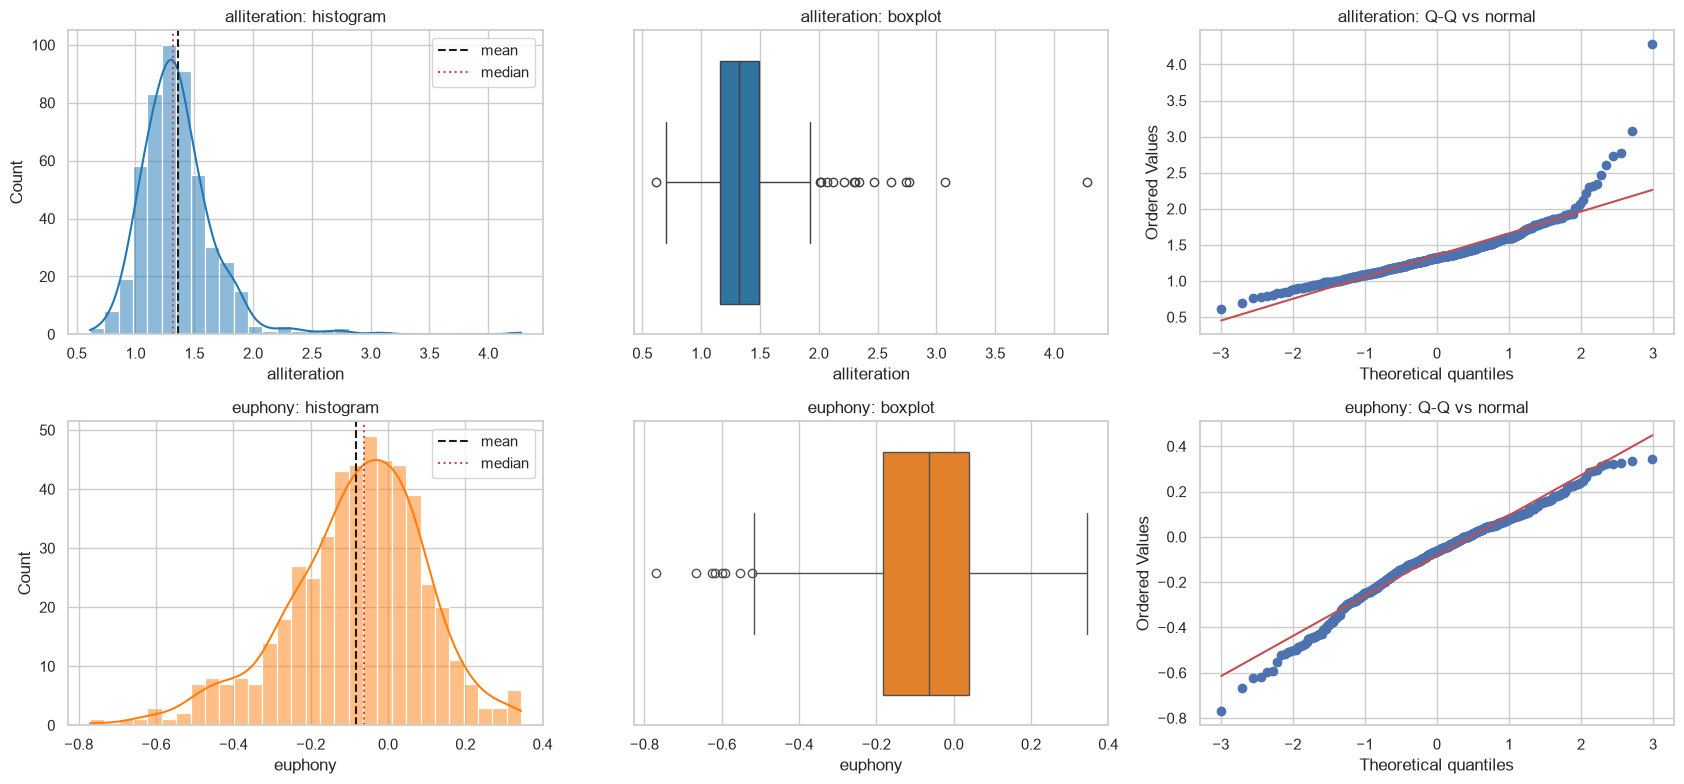

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(17, 8))
for i, (c, col) in enumerate([("alliteration", "tab:blue"), ("euphony", "tab:orange")]):
    sns.histplot(df[c], kde=True, bins=30, color=col, ax=ax[i, 0])
    ax[i, 0].axvline(df[c].mean(), c="k", ls="--", label="mean"); ax[i, 0].axvline(df[c].median(), c="r", ls=":", label="median")
    ax[i, 0].legend(); ax[i, 0].set_title(f"{c}: histogram")
    sns.boxplot(x=df[c], color=col, ax=ax[i, 1]); ax[i, 1].set_title(f"{c}: boxplot")
    stats.probplot(df[c], plot=ax[i, 2]); ax[i, 2].set_title(f"{c}: Q-Q vs normal")
plt.tight_layout(); plt.show()

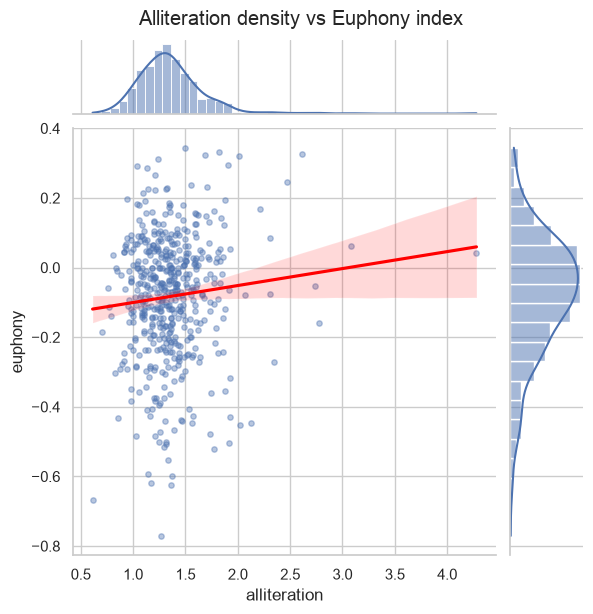

In [7]:
g = sns.jointplot(data=df, x="alliteration", y="euphony", kind="reg", height=6,
                  scatter_kws=dict(alpha=.4, s=15), line_kws=dict(color="red"))
g.fig.suptitle("Alliteration density vs Euphony index", y=1.02); plt.show()

## 4. By source

In [8]:
def grp(by):
    g = df.groupby(by)[["alliteration", "euphony"]].agg(["count", "min", "max", "mean", "std", "median"])
    return g.sort_values(("euphony", "mean"), ascending=False)
grp("source")

alliteration                                    euphony                                      
                   count    min    max   mean    std median   count     min    max    mean    std  median
source                                                                                                   
vemana                48 0.8772 2.6122 1.3408 0.3737 1.2076      48 -0.6176 0.3333  0.0300 0.1937  0.0753
generated             84 0.7647 2.0112 1.2815 0.2618 1.2786      84 -0.4314 0.3214 -0.0578 0.1386 -0.0423
kuchimanchi           69 0.8043 2.7718 1.3854 0.3198 1.3500      69 -0.5033 0.3443 -0.0676 0.1749 -0.0559
bhagavatam           226 0.7736 2.3095 1.3583 0.2416 1.3377     226 -0.6250 0.2292 -0.1091 0.1666 -0.0792
reference             73 0.6129 4.2794 1.4276 0.5256 1.3158      73 -0.7708 0.3125 -0.1194 0.2151 -0.0929

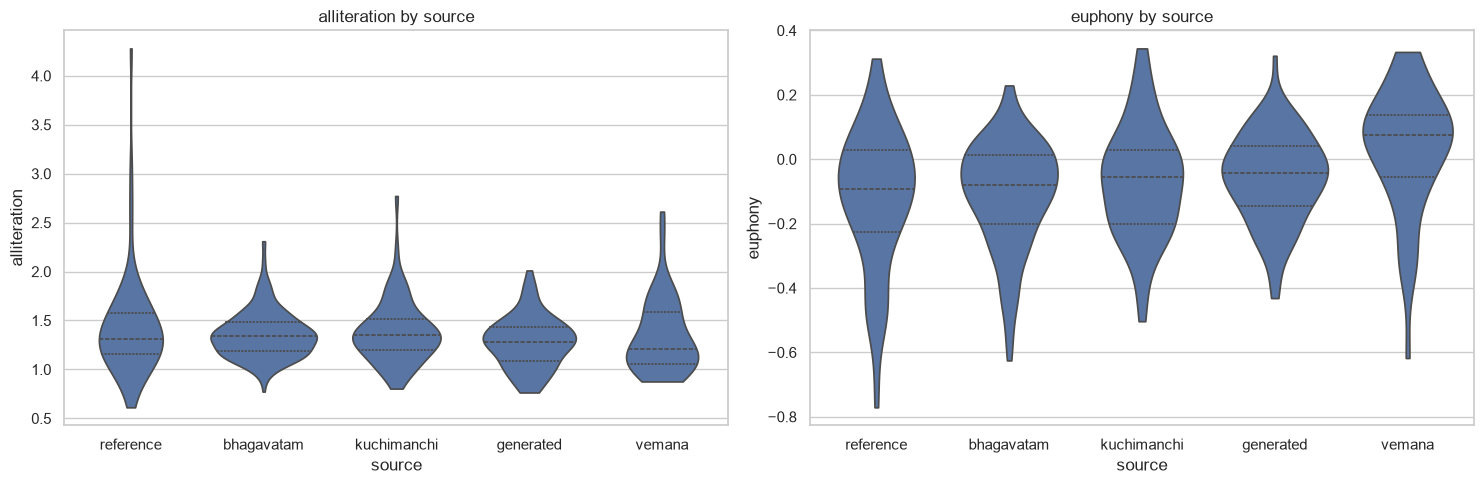

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
order = df.groupby("source").euphony.mean().sort_values().index
for a, c in zip(ax, ["alliteration", "euphony"]):
    sns.violinplot(data=df, x="source", y=c, order=order, inner="quartile", cut=0, ax=a)
    a.set_title(f"{c} by source")
plt.tight_layout(); plt.show()

In [10]:
# Do sources differ? Kruskal-Wallis (non-parametric) + pairwise Mann-Whitney (Bonferroni)
from itertools import combinations
srcs = sorted(df.source.unique())
for c in ["alliteration", "euphony"]:
    H, p = stats.kruskal(*[df[df.source == s][c] for s in srcs])
    print(f"{c}: Kruskal-Wallis H={H:.2f}, p={p:.3g}")
    pairs = list(combinations(srcs, 2)); res = []
    for a, b in pairs:
        u, pp = stats.mannwhitneyu(df[df.source == a][c], df[df.source == b][c])
        res.append((a, b, min(1.0, pp * len(pairs))))
    print(pd.DataFrame(res, columns=["A", "B", "p_bonf"]).assign(sig=lambda d: d.p_bonf < .05).to_string(index=False), "\n")

alliteration: Kruskal-Wallis H=6.39, p=0.172
          A           B  p_bonf   sig
 bhagavatam   generated  0.3865 False
 bhagavatam kuchimanchi  1.0000 False
 bhagavatam   reference  1.0000 False
 bhagavatam      vemana  1.0000 False
  generated kuchimanchi  0.8417 False
  generated   reference  1.0000 False
  generated      vemana  1.0000 False
kuchimanchi   reference  1.0000 False
kuchimanchi      vemana  1.0000 False
  reference      vemana  1.0000 False 

euphony: Kruskal-Wallis H=30.63, p=3.65e-06
          A           B  p_bonf   sig
 bhagavatam   generated  0.3111 False
 bhagavatam kuchimanchi  1.0000 False
 bhagavatam   reference  1.0000 False
 bhagavatam      vemana  0.0000  True
  generated kuchimanchi  1.0000 False
  generated   reference  1.0000 False
  generated      vemana  0.0035  True
kuchimanchi   reference  1.0000 False
kuchimanchi      vemana  0.0085  True
  reference      vemana  0.0003  True 



## 5. By meter

In [11]:
mt = grp("meter"); mt.insert(0, "n", mt[("euphony", "count")]); mt

n alliteration                                    euphony                                       
                               count    min    max   mean    std median   count     min     max    mean    std  median
meter                                                                                                                 
manini                2            2 1.2128 1.6545 1.4337 0.3124 1.4337       2  0.0455  0.2216  0.1336 0.1245  0.1336
vanamayuramu          2            2 1.0317 1.2344 1.1331 0.1433 1.1331       2 -0.1071  0.3125  0.1027 0.2967  0.1027
rathoddhata           1            1 1.0800 1.0800 1.0800    NaN 1.0800       1  0.0909  0.0909  0.0909    NaN  0.0909
madhuragati_ragada    4            4 0.8043 1.3500 1.0924 0.2243 1.1077       4  0.0000  0.1583  0.0688 0.0679  0.0585
lalita                1            1 4.2794 4.2794 4.2794    NaN 4.2794       1  0.0417  0.0417  0.0417    NaN  0.0417
mangalamahasri        4            4 1.4310 1.6500 1.5246 0.0913 1.5088       4 -0.0144  0.0433  0.0228 0.0256  0.0312
kandamu              40           40 0.7736 2.6122 1.3211 0.3727 1.2053      40 -0.3936  0.3333  0.0086 0.1922  0.0643
champakamala         40           40 1.1413 2.0112 1.3987 0.1830 1.3559      40 -0.2857  0.3214 -0.0113 0.1061 -0.0238
ataveladi            40           40 0.7647 3.0769 1.1383 0.3930 1.0476      40 -0.4314  0.2941 -0.0257 0.1719 -0.0101
sragvini              4            4 1.0508 1.6885 1.2420 0.3016 1.1143       4 -0.4271  0.3229 -0.0286 0.3074 -0.0052
indravajra            3            3 1.0167 1.5902 1.2380 0.3083 1.1071       3 -0.1818  0.0682 -0.0303 0.1332  0.0227
sragdhara             8            8 1.3048 1.8384 1.5314 0.1621 1.5298       8 -0.4405  0.2381 -0.0335 0.1985 -0.0328
layagrahi             7            7 1.7692 2.7718 2.1192 0.3975 1.9237       7 -0.5208  0.2458 -0.0339 0.2538  0.0542
taruvoja              4            4 1.3860 1.5965 1.4955 0.0878 1.4998       4 -0.2476  0.1250 -0.0356 0.1554 -0.0099
totakamu              4            4 0.9231 1.3889 1.0992 0.2072 1.0425       4 -0.2604  0.0938 -0.0365 0.1655  0.0104
layavibhati           6            6 1.7248 2.2128 1.8485 0.1941 1.7497       6 -0.3162  0.1691 -0.0368 0.1695 -0.0092
madhyakkara           2            2 1.2386 1.5765 1.4076 0.2389 1.4076       2 -0.0929  0.0128 -0.0400 0.0747 -0.0400
kavirajavirajitamu    2            2 1.1650 1.3679 1.2665 0.1435 1.2665       2 -0.0870  0.0000 -0.0435 0.0615 -0.0435
tetagiti             40           40 0.8302 1.8095 1.1500 0.2004 1.1091      40 -0.6176  0.3443 -0.0510 0.1748 -0.0329
utpalamala           40           40 1.0652 1.8632 1.4540 0.2230 1.4162      40 -0.3250  0.1750 -0.0661 0.1318 -0.0437
upendravajra          4            4 0.9091 1.7377 1.1609 0.3936 0.9984       4 -0.4773  0.0909 -0.0738 0.2698  0.0455
seesamu              40           40 1.1261 2.0708 1.5612 0.2159 1.5627      40 -0.5033  0.1951 -0.1105 0.1371 -0.0890
pamcacamaramu         5            5 1.1795 1.4800 1.3256 0.1067 1.3158       5 -0.5000  0.2266 -0.1219 0.3303 -0.1094
mattebhavikriditamu  40           40 1.0860 1.7353 1.3312 0.1412 1.3128      40 -0.6250  0.1562 -0.1273 0.1621 -0.1000
sardulavikriditamu   40           40 1.0323 2.1250 1.3641 0.1838 1.3595      40 -0.4474  0.1513 -0.1281 0.1598 -0.1447
mattakokilamu        40           40 1.0247 1.9239 1.3711 0.2199 1.3314      40 -0.5069  0.1528 -0.1306 0.1718 -0.1007
taralamu             24           24 1.0723 2.3095 1.3943 0.2505 1.3486      24 -0.5987  0.0855 -0.1346 0.1769 -0.0954
utsahamu             18           18 1.0263 2.7381 1.3460 0.3774 1.2591      18 -0.5917  0.1048 -0.1429 0.2041 -0.0809
salini                1            1 1.1000 1.1000 1.1000    NaN 1.1000       1 -0.1477 -0.1477 -0.1477    NaN -0.1477
malini               15           15 0.9403 1.5949 1.2614 0.1896 1.2206      15 -0.3750  0.0667 -0.1817 0.1183 -0.1667
mahasragdhara         6            6 1.2430 1.5743 1.3823 0.1381 1.3741       6 -0.4716 -0.0795

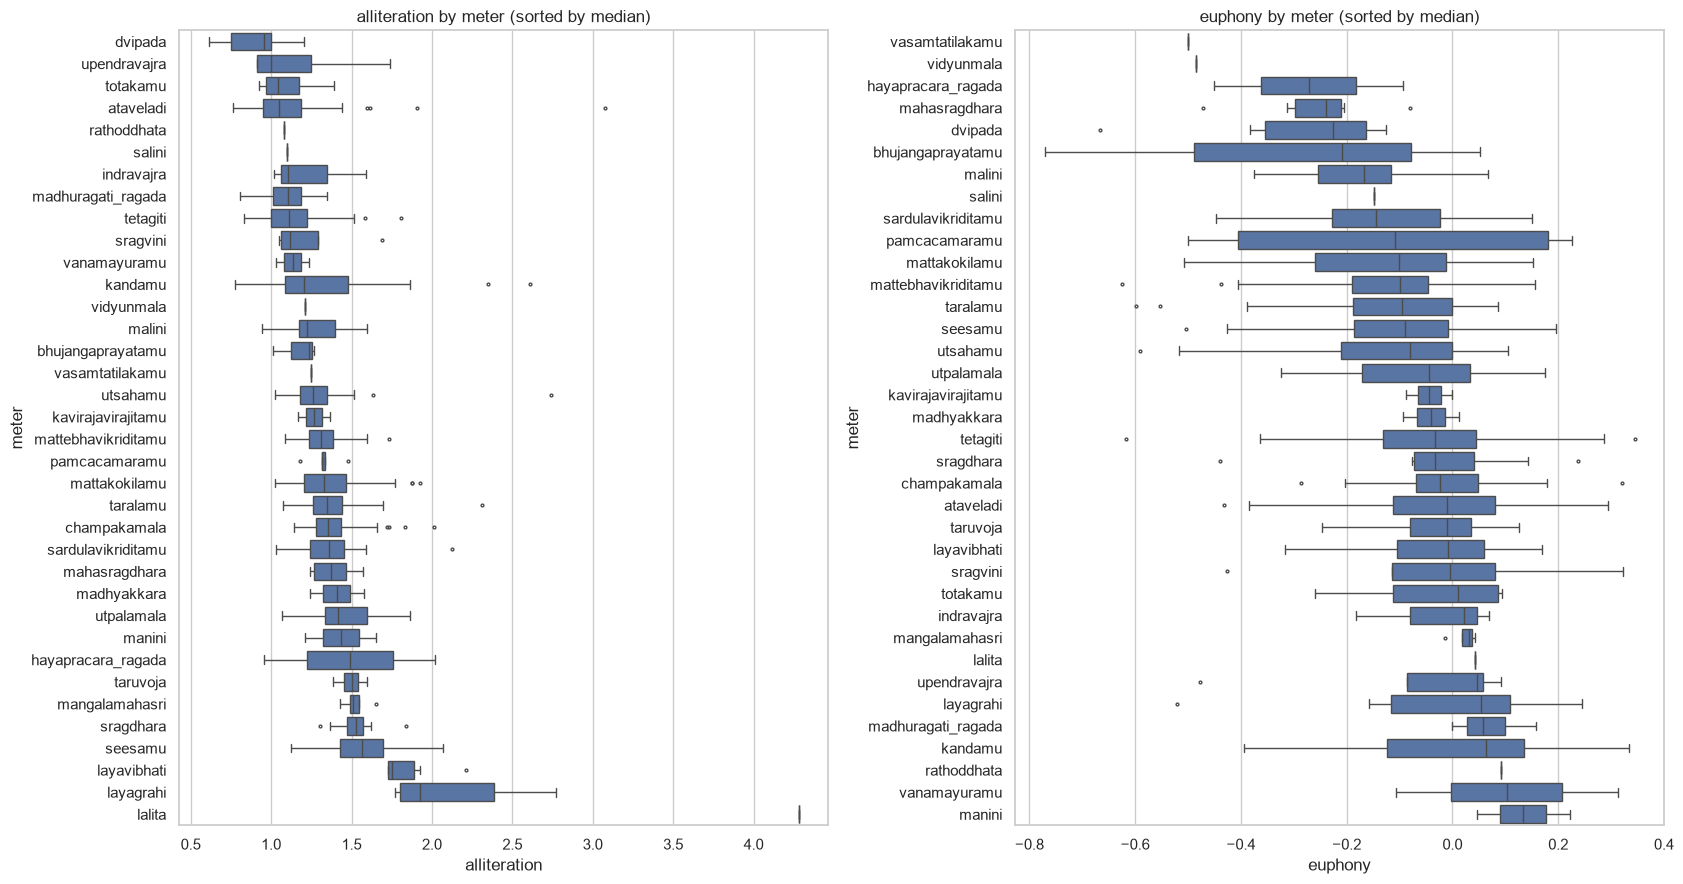

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(17, 9))
for a, c in zip(ax, ["alliteration", "euphony"]):
    o = df.groupby("meter")[c].median().sort_values().index
    sns.boxplot(data=df, y="meter", x=c, order=o, ax=a, fliersize=2); a.set_title(f"{c} by meter (sorted by median)")
plt.tight_layout(); plt.show()

In [13]:
for c in ["alliteration", "euphony"]:
    big = df.groupby("meter").filter(lambda d: len(d) >= 5)
    H, p = stats.kruskal(*[g[c] for _, g in big.groupby("meter")])
    print(f"{c} across meters (n>=5): Kruskal-Wallis H={H:.1f}, p={p:.3g}")

alliteration across meters (n>=5): Kruskal-Wallis H=161.5, p=1.37e-25
euphony across meters (n>=5): Kruskal-Wallis H=61.8, p=5.19e-07


## 6. Other slices (strictest profile, poem length)

In [14]:
display(grp("strictest"))
df["len_bin"] = pd.qcut(df.consonants, 4, labels=["Q1 short", "Q2", "Q3", "Q4 long"])
display(df.groupby("len_bin")[["alliteration", "euphony", "consonants"]].agg(["mean", "std", "median"]))
rho1 = stats.spearmanr(df.consonants, df.alliteration); rho2 = stats.spearmanr(df.consonants, df.euphony)
print(f"Spearman(length, alliteration) = {rho1.statistic:.3f} (p={rho1.pvalue:.3g}); Spearman(length, euphony) = {rho2.statistic:.3f} (p={rho2.pvalue:.3g})")

alliteration                                    euphony                                      
                 count    min    max   mean    std median   count     min    max    mean    std  median
strictest                                                                                              
relaxed             10 1.1625 1.7727 1.4364 0.1987 1.3833      10 -0.5208 0.1250 -0.0473 0.1894  0.0293
strict             490 0.6129 4.2794 1.3560 0.3284 1.3161     490 -0.7708 0.3443 -0.0836 0.1787 -0.0652

alliteration               euphony                consonants                 
                 mean    std median    mean    std  median       mean     std   median
len_bin                                                                               
Q1 short       1.1846 0.3478 1.0963 -0.0415 0.1991  0.0000    54.4848  6.2180  56.0000
Q2             1.3406 0.3623 1.2925 -0.1090 0.1816 -0.0933    76.4016  9.0605  79.5000
Q3             1.3755 0.1973 1.3441 -0.0863 0.1658 -0.0625    92.7054  2.3399  93.0000
Q4 long        1.5507 0.2632 1.5096 -0.0987 0.1585 -0.0774   117.1197 23.4536 110.0000

Spearman(length, alliteration) = 0.574 (p=3.95e-45); Spearman(length, euphony) = -0.117 (p=0.00865)


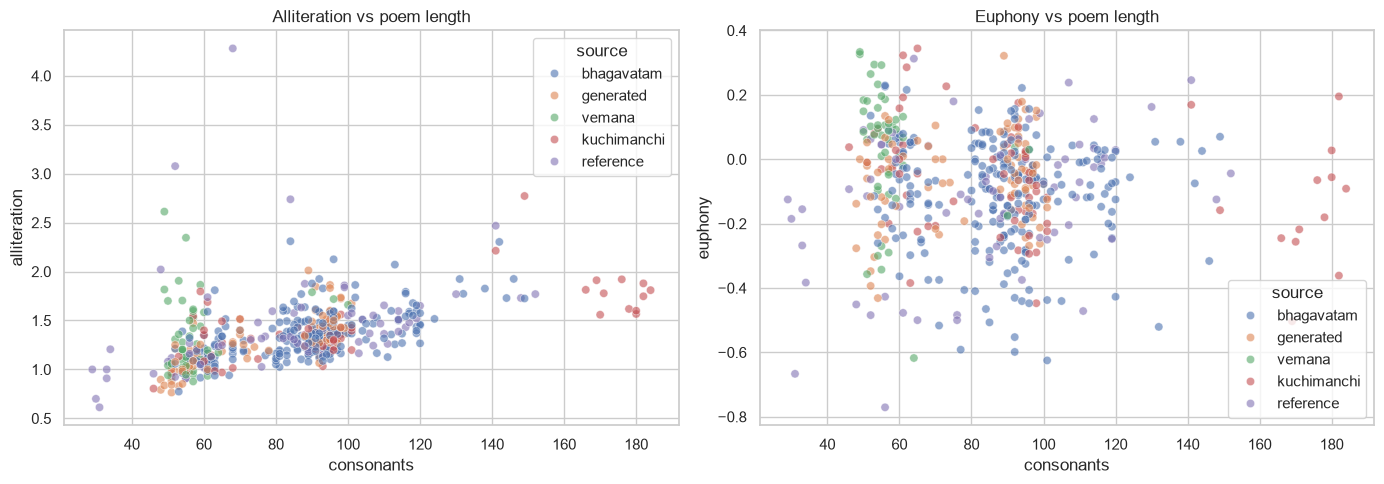

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="consonants", y="alliteration", hue="source", alpha=.6, ax=ax[0]); ax[0].set_title("Alliteration vs poem length")
sns.scatterplot(data=df, x="consonants", y="euphony", hue="source", alpha=.6, ax=ax[1]); ax[1].set_title("Euphony vs poem length")
plt.tight_layout(); plt.show()

## 7. Euphony components & correlations
`M = I − P`: how much of the score is the plain class inventory vs the harsh-run pile-up, plus the rubric-level distribution against the reference-corpus baseline.

Rubric level distribution (reference-corpus cut points; 10/20/40/20/10% expected if same distribution):


,share
label,
harsh,0.1260
leaning_harsh,0.2320
balanced,0.4240
leaning_soft,0.1520
soft,0.0660


Mean class shares:


,mean_share
share_madhura,0.1173
share_sonorant,0.3794
share_voiced,0.1408
share_voiceless,0.1921
share_conjunct,0.0333
share_parusha,0.1370


mean I=0.0573, mean P=0.1402, mean M=-0.0829
Spearman(madhurya, sonority) = 0.491 (p=9.55e-32)


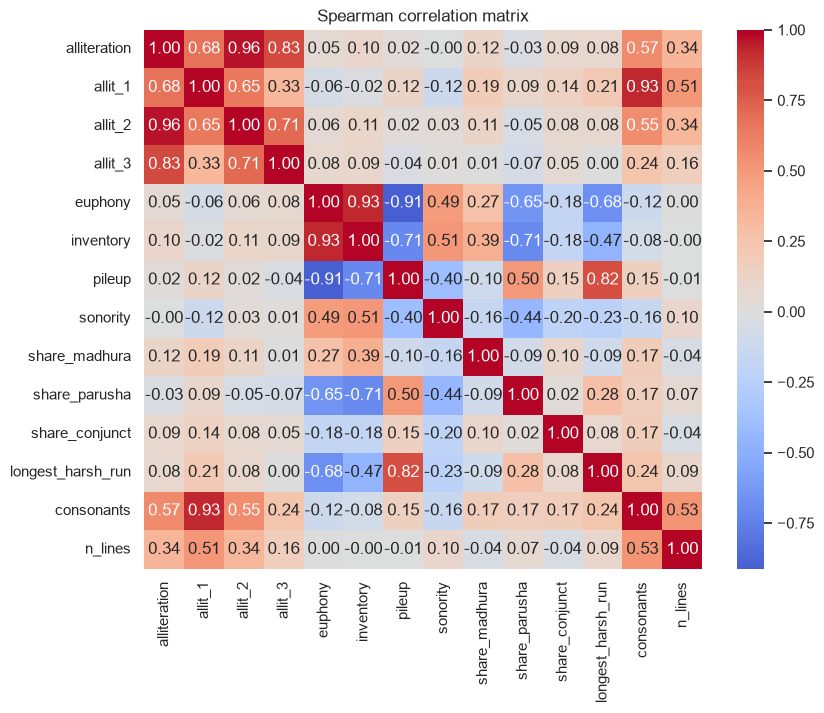

In [16]:
print("Rubric level distribution (reference-corpus cut points; 10/20/40/20/10% expected if same distribution):")
display(df.label.value_counts(normalize=True).reindex(md.LABELS).to_frame("share"))
print("Mean class shares:"); display(df[[f"share_{c}" for c in CLASSES]].mean().to_frame("mean_share"))
print(f"mean I={df.inventory.mean():.4f}, mean P={df.pileup.mean():.4f}, mean M={df.euphony.mean():.4f}")
rs = stats.spearmanr(df.euphony, df.sonority); print(f"Spearman(madhurya, sonority) = {rs.statistic:.3f} (p={rs.pvalue:.3g})")
cols = ["alliteration", "allit_1", "allit_2", "allit_3", "euphony", "inventory", "pileup", "sonority", "share_madhura", "share_parusha", "share_conjunct", "longest_harsh_run", "consonants", "n_lines"]
plt.figure(figsize=(9, 7)); sns.heatmap(df[cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation matrix"); plt.show()

## 8. Extremes & outliers

In [17]:
show = lambda d: d.assign(first_line=d.eval_id.map({p["eval_id"]: p["lines"][0] for p in poems}))[
    ["eval_id", "source", "meter", "alliteration", "euphony", "consonants", "first_line"]]
for c in ["alliteration", "euphony"]:
    print(f"\n=== Top 5 highest {c} ==="); display(show(df.nlargest(5, c)))
    print(f"=== Top 5 lowest {c} ==="); display(show(df.nsmallest(5, c)))


=== Top 5 highest alliteration ===


,eval_id,source,meter,alliteration,euphony,consonants,first_line
193,he_0194,reference,lalita,4.2794,0.0417,68,తాల్చు న్నభాశి లలితన్ తభల్ జరల్
130,he_0131,reference,ataveladi,3.0769,0.0625,52,ఇనగణత్రయంబునింద్రద్వయంబును
381,he_0382,kuchimanchi,layagrahi,2.7718,-0.1583,149,గట్టులును జట్టులును జెట్టులును బట్టుకొని నెట్ట...
76,he_0077,reference,utsahamu,2.7381,-0.0542,84,చలికి వణకె చేతు లిచట చలికి కాళ్ళు వణకెరా
40,he_0041,vemana,kandamu,2.6122,0.3261,49,ఏవంక మనసు కలిగిన


=== Top 5 lowest alliteration ===


,eval_id,source,meter,alliteration,euphony,consonants,first_line
260,he_0261,reference,dvipada,0.6129,-0.6667,31,ఇంద్ర గణములు మూఁ డిన గణంబొకటి
35,he_0036,reference,dvipada,0.7000,-0.1852,30,నడురాత్రి యరుదెంచెనరలోకనాధ
38,he_0039,generated,ataveladi,0.7647,-0.0600,51,"కంటి నిండ నిదుర కానని వేళల,"
351,he_0352,bhagavatam,kandamu,0.7736,-0.1146,53,తాననుగమనము చేయం
100,he_0101,generated,ataveladi,0.7917,-0.1383,48,"ఎండ వాన లనక యేడు ముక్కా లాడి,"



=== Top 5 highest euphony ===


,eval_id,source,meter,alliteration,euphony,consonants,first_line
347,he_0348,kuchimanchi,tetagiti,1.4923,0.3443,65,బిత్తరపు గుబ్బ లేపునఁ బెరుఁగు నంచు
259,he_0260,vemana,kandamu,1.8163,0.3333,49,వేమన్నా నీమహిమలు
40,he_0041,vemana,kandamu,2.6122,0.3261,49,ఏవంక మనసు కలిగిన
420,he_0421,kuchimanchi,sragvini,1.6885,0.3229,61,చీమలుం దోమలుం జెట్టులుం గట్టులుం
24,he_0025,generated,champakamala,2.0112,0.3214,89,గురుని ప్రబోధ డెందముల గోరి నయంబు నొసంగు బోధమున్


=== Top 5 lowest euphony ===


,eval_id,source,meter,alliteration,euphony,consonants,first_line
349,he_0350,reference,bhujangaprayatamu,1.2679,-0.7708,56,హరీ ! చక్రధారీ ! మురారీ ! త్రిధామా !
260,he_0261,reference,dvipada,0.6129,-0.6667,31,ఇంద్ర గణములు మూఁ డిన గణంబొకటి
283,he_0284,bhagavatam,mattebhavikriditamu,1.3663,-0.6250,101,విహగేంద్రుం డహి వ్రచ్చుకైవడి మహోద్వృత్తిన్ నృస...
462,he_0463,vemana,tetagiti,1.1719,-0.6176,64,ప్రాఁతచేసిన నర్తనల్‌ పదటఁగలిపి
415,he_0416,bhagavatam,taralamu,1.3696,-0.5987,92,వినుఁడు నేను మహేంద్రుఁ డప్పతి వీతిహోత్రుఁడు రా...


In [18]:
for c in ["alliteration", "euphony"]:
    q1, q3 = df[c].quantile([.25, .75]); i = q3 - q1
    out = df[(df[c] < q1 - 1.5 * i) | (df[c] > q3 + 1.5 * i)]
    z = (df[c] - df[c].mean()) / df[c].std()
    print(f"{c}: {len(out)} IQR outliers ({len(out)/len(df):.1%}); |z|>3: {(z.abs() > 3).sum()}")
print("\nMost frequent top-repeated consonant sequences:")
print(pd.Series([r[0] for r in df.top_repeat.dropna()]).value_counts().head(10))

alliteration: 15 IQR outliers (3.0%); |z|>3: 7
euphony: 8 IQR outliers (1.6%); |z|>3: 3

Most frequent top-repeated consonant sequences:
n     249
l      76
r      61
M      22
dh     15
th     13
v       9
kh      9
Th      8
Dh      7
Name: count, dtype: int64


## 9. Summary

In [19]:
s = summary
print(f"Alliteration density: mean {s.loc['mean','alliteration']:.3f} ± {s.loc['std','alliteration']:.3f} (min {s.loc['min','alliteration']:.3f}, median {s.loc['median','alliteration']:.3f}, max {s.loc['max','alliteration']:.3f}), skew {s.loc['skew','alliteration']:.2f}")
print(f"Euphony index:        mean {s.loc['mean','euphony']:.3f} ± {s.loc['std','euphony']:.3f} (min {s.loc['min','euphony']:.3f}, median {s.loc['median','euphony']:.3f}, max {s.loc['max','euphony']:.3f}), skew {s.loc['skew','euphony']:.2f}")
print(f"Metric correlation:   Pearson {r:.3f}, Spearman {rho:.3f}")
print(f"Share of poems with euphony > 0 (net soft): {(df.euphony > 0).mean():.1%}; mean rubric level {df.level.mean():.2f}")
print(f"Highest-euphony source: {df.groupby('source').euphony.mean().idxmax()}; highest-alliteration source: {df.groupby('source').alliteration.mean().idxmax()}")

Alliteration density: mean 1.358 ± 0.326 (min 0.613, median 1.318, max 4.279), skew 2.45
Euphony index:        mean -0.083 ± 0.179 (min -0.771, median -0.063, max 0.344), skew -0.57
Metric correlation:   Pearson 0.089, Spearman 0.051
Share of poems with euphony > 0 (net soft): 33.2%; mean rubric level 1.80
Highest-euphony source: vemana; highest-alliteration source: reference
